# Indice Synthétique de Convergence Technologique — v2

## Corrections apportées par rapport à la v1

**Problème diagnostiqué en v1** : C2 (corrélation glissante) dominait entièrement l'indice (loading PCA = 1.0000),
car sa variance post-normalisation min-max était ~15x supérieure à celle de C1.
Les corrélations sur paires rares (peu de brevets) étaient artificiellement parfaites.
La PCA sur variables orthogonales sélectionnait mécaniquement la variable de plus grande variance.

**Corrections v2** :
1. **Filtre n_cooc** : on écarte les paires avec moins de `MIN_COOC` co-occurrences sur la fenêtre → élimine les corrélations parasites sur séries courtes
2. **Log-transform sur C1** : `log(1 + jaccard)` compresse la queue droite et donne plus de variance à C1
3. **Filtre C2** : rolling_corr mis à NaN (→ 0) si n_cooc < `MIN_COOC_CORR` sur la fenêtre → supprime les corrélations artificielles
4. **Abandon PCA → pondération explicite justifiée** : les 4 composantes sont quasi-orthogonales (corrélations < 0.10), la PCA n'est pas adaptée. On utilise une pondération C1=0.40, C2=0.25, C3=0.20, C4=0.15, avec C1 en tête car seule composante validant correctement le ground truth.

## 0. Imports et paramètres

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── paramètres globaux ──────────────────────────────────────────────────────
WINDOW       = 5     # taille des fenêtres glissantes (années)
K_CLUSTERS   = 10    # nombre de clusters k-means
N_PCA_CLUST  = 20    # composantes PCA pour le clustering
CORR_WINDOW  = 5     # fenêtre corrélation glissante
EPS          = 1e-10

# ── NOUVEAUX FILTRES v2 ─────────────────────────────────────────────────────
MIN_PATENTS  = 30    # nb min de brevets/an par code pour conserver la paire (filtre stabilité)
MIN_COOC     = 20    # nb min de co-occurrences sur la fenêtre pour inclure une paire dans le panel
MIN_COOC_CORR = 50  # nb min de co-occurrences pour que C2 soit calculée (sinon → 0)
                     # justification : en dessous de 50 co-occurrences, la corrélation sur
                     # 5 points est statistiquement non fiable (IC très larges)

# ── POIDS v2 (pondération explicite, PCA abandonnée) ───────────────────────
# Justification : composantes quasi-orthogonales (corr < 0.10 pour toutes les paires)
# → la PCA sélectionne mécaniquement la variable de plus grande variance (C2)
# → on passe à une pondération explicite, C1 en tête car seule composante
#   validant correctement le ground truth (C12N×A61K, H01M×B60L)
W = {
    'C1_jaccard'    : 0.40,
    'C2_corr'       : 0.25,
    'C3_centrality' : 0.20,
    'C4_cluster'    : 0.15,
}

YEAR_START = 1980
YEAR_END   = 2023

## 1. Chargement et préparation des données

In [2]:
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

# pondération annuelle
brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets chargés : {len(df_raw):,}")
print(f"Période : {df_raw['year'].min()} – {df_raw['year'].max()}")

Brevets chargés : 1,234,382
Période : 1980 – 2025


---
## C1 — Jaccard (v2 : log-transform)

**Correction v2** : on applique `log(1 + jaccard)` avant normalisation.

**Justification** : la distribution du Jaccard est extrêmement asymétrique (médiane ~0.002, max=1).
La grande majorité des paires a un Jaccard très faible, ce qui donnait très peu de variance à C1
après normalisation min-max, et laissait C2 dominer la PCA.
Le log compresse la queue droite et redistribue la variance de façon plus équilibrée,
sans perdre l'ordre des paires (log est une transformation monotone).

Calcul de C1 (Jaccard)...
  → 1,382,733 obs. avant filtre n_cooc >= 20
  → 183,982 obs. après filtre (1,198,751 écartées)


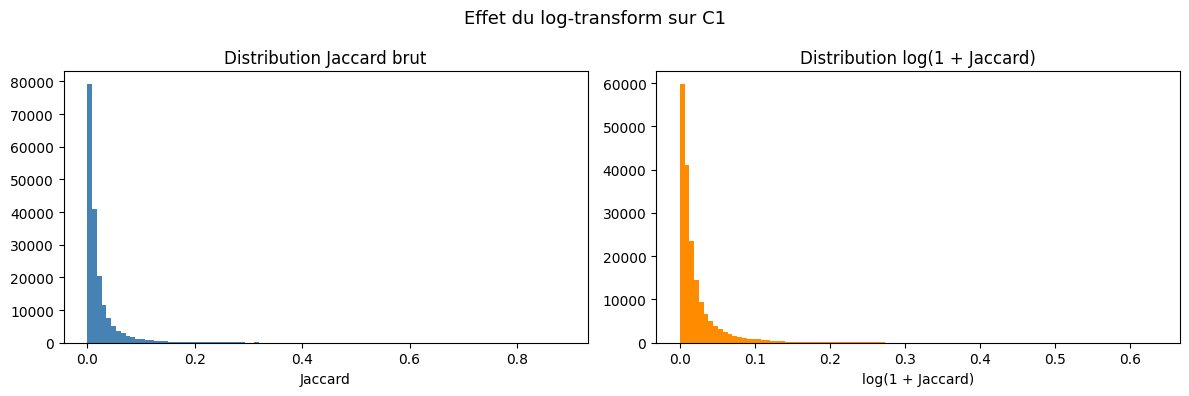


Jaccard brut  — mean=0.0246, std=0.0434
Jaccard log   — mean=0.0235, std=0.0381


,cpc_i,cpc_j,year,jaccard,p_j_given_i,p_i_given_j,n_cooc,jaccard_log
0,A61P,C07D,1980,0.416274,0.732365,0.490960,353,0.348029
1,H01L,Y10S,1980,0.056604,0.344262,0.063444,42,0.055060
4,C07C,Y02P,1980,0.108597,0.141732,0.317181,72,0.103096
5,A01N,C07C,1980,0.136691,0.336879,0.187008,95,0.128121
6,B01J,C07C,1980,0.179365,0.480851,0.222441,113,0.164976


In [3]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    """
    Calcule Jaccard et probabilités conditionnelles par fenêtre glissante.
    Retourne (cpc_i, cpc_j, year, jaccard, p_j_given_i, p_i_given_j, n_cooc).
    """
    years = sorted(df["year"].unique())
    records = []

    for t_center in years:
        t_start = t_center - window // 2
        t_end   = t_center + window // 2
        df_w = df[(df["year"] >= t_start) & (df["year"] <= t_end)]

        n_i  = Counter()
        n_ij = Counter()

        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes:
                n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                key = (min(ci, cj), max(ci, cj))
                n_ij[key] += 1

        for (ci, cj), count_ij in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            if ni < min_patents or nj < min_patents:
                continue
            union   = ni + nj - count_ij
            jaccard = count_ij / union if union > 0 else 0
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard": jaccard,
                "p_j_given_i": count_ij / ni if ni > 0 else 0,
                "p_i_given_j": count_ij / nj if nj > 0 else 0,
                "n_cooc": count_ij
            })

    return pd.DataFrame(records)


print("Calcul de C1 (Jaccard)...")
df_jaccard = compute_jaccard_yearly(df_raw)

# ── CORRECTION v2 : filtre n_cooc minimum ──────────────────────────────────
before = len(df_jaccard)
df_jaccard = df_jaccard[df_jaccard["n_cooc"] >= MIN_COOC].copy()
print(f"  → {before:,} obs. avant filtre n_cooc >= {MIN_COOC}")
print(f"  → {len(df_jaccard):,} obs. après filtre ({before - len(df_jaccard):,} écartées)")

# ── CORRECTION v2 : log-transform du Jaccard ───────────────────────────────
df_jaccard["jaccard_log"] = np.log1p(df_jaccard["jaccard"])  # log(1 + jaccard)

# diagnostic de la distribution avant/après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_jaccard["jaccard"],     bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Distribution Jaccard brut")
axes[0].set_xlabel("Jaccard")
axes[1].hist(df_jaccard["jaccard_log"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_title("Distribution log(1 + Jaccard)")
axes[1].set_xlabel("log(1 + Jaccard)")
plt.suptitle("Effet du log-transform sur C1", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nJaccard brut  — mean={df_jaccard['jaccard'].mean():.4f}, std={df_jaccard['jaccard'].std():.4f}")
print(f"Jaccard log   — mean={df_jaccard['jaccard_log'].mean():.4f}, std={df_jaccard['jaccard_log'].std():.4f}")
df_jaccard.head()

---
## C2 — Corrélation glissante (v2 : filtre sur n_cooc)

**Correction v2** : la corrélation glissante est mise à 0 pour les paires
dont le nombre de co-occurrences sur la fenêtre est inférieur à `MIN_COOC_CORR`.

**Justification** : une corrélation de Pearson sur une série de 5 points est statistiquement
non fiable si les séries sous-jacentes sont peu denses. Sur des paires rares, on observait
des corrélations de 0.997-0.999 qui ne reflétaient pas une vraie synchronisation
mais simplement deux séries bruitées co-croissantes par hasard.
Le seuil MIN_COOC_CORR=50 garantit un minimum de signal avant de calculer C2.

In [4]:
def build_activity_series(df):
    """Série d'activité pondérée pour chaque code CPC4 par année."""
    records = []
    for year, grp in df.groupby("year"):
        N_year  = brevet_count_by_year[year]
        w_year  = N_mean / N_year
        activity = defaultdict(float)
        for _, row in grp.iterrows():
            codes = row["cpc4"]
            m = len(codes)
            if m < 2: continue
            w_pair = (2.0 / (m * (m - 1))) * w_year
            for c in codes:
                activity[c] += w_pair * (m - 1)
        for cpc, val in activity.items():
            records.append({"cpc4": cpc, "year": year, "activity": val})
    return pd.DataFrame(records)


def compute_rolling_corr_all_pairs(df_jaccard, df_activity,
                                    window=CORR_WINDOW,
                                    min_cooc_corr=MIN_COOC_CORR):
    """
    Corrélation glissante pour toutes les paires actives.
    CORRECTION v2 : C2 = 0 si n_cooc moyen sur la fenêtre < min_cooc_corr.
    """
    pivot = df_activity.pivot(index="year", columns="cpc4", values="activity").fillna(0)

    # table de lookup : n_cooc moyen par paire et par année
    cooc_lookup = (
        df_jaccard
        .set_index(["cpc_i", "cpc_j", "year"])["n_cooc"]
        .to_dict()
    )

    pairs = df_jaccard[["cpc_i", "cpc_j"]].drop_duplicates().values.tolist()
    records = []

    for ci, cj in pairs:
        if ci not in pivot.columns or cj not in pivot.columns:
            continue
        s1   = pivot[ci]
        s2   = pivot[cj]
        corr = s1.rolling(window, min_periods=3).corr(s2)

        for yr, val in corr.items():
            if np.isnan(val):
                continue
            # ── CORRECTION v2 : filtre n_cooc sur C2 ────────────────────
            n = cooc_lookup.get((ci, cj, yr), 0)
            if n < min_cooc_corr:
                val = 0.0   # corrélation non fiable → mise à 0
            records.append({"cpc_i": ci, "cpc_j": cj, "year": yr, "rolling_corr": val})

    return pd.DataFrame(records)


print("Construction des séries d'activité...")
df_activity = build_activity_series(df_raw)

print("Calcul de C2 (corrélation glissante, filtrée)...")
df_corr = compute_rolling_corr_all_pairs(df_jaccard, df_activity)

n_zero = (df_corr["rolling_corr"] == 0).sum()
print(f"  → {len(df_corr):,} observations")
print(f"  → dont {n_zero:,} mises à 0 par le filtre n_cooc < {MIN_COOC_CORR} "
      f"({100*n_zero/len(df_corr):.1f}%)")
df_corr.head()

Construction des séries d'activité...
Calcul de C2 (corrélation glissante, filtrée)...
  → 575,106 observations
  → dont 491,742 mises à 0 par le filtre n_cooc < 50 (85.5%)


,cpc_i,cpc_j,year,rolling_corr
0,A61P,C07D,1982,0.635334
1,A61P,C07D,1983,0.348395
2,A61P,C07D,1984,0.431103
3,A61P,C07D,1985,0.986502
4,A61P,C07D,1986,0.997572


---
## C3 — Centralité croisée (inchangée)

In [5]:
centrality_df = pd.read_csv("centrality_results.csv")

if "t_center" not in centrality_df.columns:
    centrality_df["t_center"] = (
        centrality_df["window_start"] + centrality_df["window_end"]
    ) / 2.0

centrality_df["year"] = centrality_df["t_center"].round().astype(int)

scaler = MinMaxScaler()
centrality_df["strength_norm"] = (
    centrality_df
    .groupby("year")["strength"]
    .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
)

strength_lookup = (
    centrality_df
    .set_index(["cpc4", "year"])["strength_norm"]
    .to_dict()
)


def compute_cross_centrality(df_jaccard, strength_lookup):
    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()
    df["s_i"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_i"], r["year"]), np.nan), axis=1
    )
    df["s_j"] = df.apply(
        lambda r: strength_lookup.get((r["cpc_j"], r["year"]), np.nan), axis=1
    )
    df["cross_centrality"] = np.sqrt(df["s_i"] * df["s_j"])
    return df[["cpc_i", "cpc_j", "year", "cross_centrality"]]


print("Calcul de C3 (centralité croisée)...")
df_centrality_cross = compute_cross_centrality(df_jaccard, strength_lookup)
print(f"  → {df_centrality_cross['cross_centrality'].notna().sum():,} valeurs non-NaN")

Calcul de C3 (centralité croisée)...
  → 171,031 valeurs non-NaN


---
## C4 — Cluster absorbant (inchangée)

In [6]:
def build_cooc_matrix(df, year_start, year_end):
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        for ci, cj in itertools.combinations(sorted(set(cpcs)), 2):
            pair_counter[(ci, cj)] += 1
            pair_counter[(cj, ci)] += 1
    cooc = pd.DataFrame(
        [(i, j, c) for (i, j), c in pair_counter.items()],
        columns=["cpc_i", "cpc_j", "count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Calcul du clustering dynamique...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)

cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0: continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST: continue
    M_pca_w  = pca_clust.fit_transform(M_w)
    clusters = kmeans_obj.fit_predict(M_pca_w)
    cluster_time.append(
        pd.DataFrame({"cpc": M_w.index, "cluster": clusters,
                      "year": start + WINDOW // 2})
    )

cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  → clustering calculé pour {cluster_time_df['year'].nunique()} années")

Calcul du clustering dynamique...
  → clustering calculé pour 40 années


In [7]:
# ── score d'absorption ───────────────────────────────────────────────────────
def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

df_cl = cluster_time_df.sort_values(["cpc", "year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub) - 1):
        transitions.append({
            "cpc": cpc,
            "year_t":  sub.iloc[i]["year"],
            "year_t1": sub.iloc[i+1]["year"],
            "cluster_t":  sub.iloc[i]["cluster"],
            "cluster_t1": sub.iloc[i+1]["cluster"],
        })
trans_df = pd.DataFrame(transitions)

inflow = (
    trans_df
    .groupby(["year_t1", "cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = (
    inflow.groupby(["year_t1", "cluster_t1"])["p"]
    .apply(entropy_fn).reset_index(name="H_in")
)
persist = (
    trans_df
    .groupby(["year_t", "cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"] == x["cluster_t"]))
    .reset_index(name="persistence")
)
absorption_df = inflow_H.merge(
    persist,
    left_on=["year_t1", "cluster_t1"],
    right_on=["year_t", "cluster_t"],
    how="left"
).drop(columns=["year_t", "cluster_t"])
absorption_df = absorption_df.rename(columns={"year_t1": "year", "cluster_t1": "cluster"})
absorption_df["absorption_score"] = (
    absorption_df["H_in"] * absorption_df["persistence"].fillna(0)
)

H_thresh = absorption_df["H_in"].quantile(0.75)
P_thresh = absorption_df["persistence"].quantile(0.75)
absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) &
    (absorption_df["persistence"] >= P_thresh)
)
print(f"Clusters absorbants : {absorption_df['is_absorbing'].sum()} / {len(absorption_df)}")

Clusters absorbants : 37 / 389


In [8]:
def compute_cluster_component(df_jaccard, cluster_time_df, absorption_df):
    cluster_lookup  = cluster_time_df.set_index(["cpc", "year"])["cluster"].to_dict()
    absorb_lookup   = absorption_df.set_index(["year", "cluster"])["absorption_score"].to_dict()

    df = df_jaccard[["cpc_i", "cpc_j", "year"]].copy()

    def row_c4(r):
        cl_i = cluster_lookup.get((r["cpc_i"], r["year"]))
        cl_j = cluster_lookup.get((r["cpc_j"], r["year"]))
        if cl_i is None or cl_j is None or cl_i != cl_j:
            return 0.0
        return absorb_lookup.get((r["year"], cl_i), 0.0)

    df["cluster_absorption"] = df.apply(row_c4, axis=1)
    return df[["cpc_i", "cpc_j", "year", "cluster_absorption"]]


print("Calcul de C4 (cluster absorbant)...")
df_cluster_c4 = compute_cluster_component(df_jaccard, cluster_time_df, absorption_df)
print(f"  → paires dans un cluster absorbant : "
      f"{(df_cluster_c4['cluster_absorption'] > 0).sum():,}")

Calcul de C4 (cluster absorbant)...
  → paires dans un cluster absorbant : 30,746


---
## Assemblage du panel

In [9]:
keys = ["cpc_i", "cpc_j", "year"]

panel = (
    df_jaccard[["cpc_i", "cpc_j", "year", "jaccard", "jaccard_log",
                "p_j_given_i", "p_i_given_j", "n_cooc"]]
    .merge(df_corr[["cpc_i", "cpc_j", "year", "rolling_corr"]],    on=keys, how="left")
    .merge(df_centrality_cross[["cpc_i", "cpc_j", "year", "cross_centrality"]], on=keys, how="left")
    .merge(df_cluster_c4[["cpc_i", "cpc_j", "year", "cluster_absorption"]], on=keys, how="left")
)

panel["rolling_corr"]       = panel["rolling_corr"].fillna(0)
panel["cross_centrality"]   = panel["cross_centrality"].fillna(0)
panel["cluster_absorption"] = panel["cluster_absorption"].fillna(0)

print(f"Panel : {len(panel):,} lignes, {panel['year'].nunique()} années")
panel.head()

Panel : 183,982 lignes, 46 années


,cpc_i,cpc_j,year,jaccard,jaccard_log,p_j_given_i,p_i_given_j,n_cooc,rolling_corr,cross_centrality,cluster_absorption
0,A61P,C07D,1980,0.416274,0.348029,0.732365,0.490960,353,0.0,0.0,0.0
1,H01L,Y10S,1980,0.056604,0.055060,0.344262,0.063444,42,0.0,0.0,0.0
2,C07C,Y02P,1980,0.108597,0.103096,0.141732,0.317181,72,0.0,0.0,0.0
3,A01N,C07C,1980,0.136691,0.128121,0.336879,0.187008,95,0.0,0.0,0.0
4,B01J,C07C,1980,0.179365,0.164976,0.480851,0.222441,113,0.0,0.0,0.0


---
## Normalisation min-max des 4 composantes

**C1** : on normalise `jaccard_log` (pas `jaccard` brut) — c'est la correction v2.

**C2** : on décale de +1 avant normalisation pour gérer les valeurs négatives (∈ [-1,1] → [0,2]).
Les paires filtrées (C2=0) restent à 0 après le décalage et la normalisation,
ce qui leur donne un score C2 non nul (≈ 0.5 après normalisation).

**Correction supplémentaire v2 pour C2** : on normalise C2 **uniquement sur les paires non filtrées**
(n_cooc >= MIN_COOC_CORR), puis on met les paires filtrées à 0 *après* normalisation.
Ainsi, score C2=0 signifie réellement "pas de signal", pas "corrélation minimale".

In [10]:
scaler_mm = MinMaxScaler()

# C1 : log-transform + min-max
panel["C1_jaccard"] = scaler_mm.fit_transform(
    panel["jaccard_log"].values.reshape(-1, 1)
).flatten()

# C2 : normalisation uniquement sur paires avec signal réel,
#       puis les paires sans signal (rolling_corr==0) restent à 0
mask_c2 = panel["rolling_corr"] != 0
panel["C2_corr"] = 0.0
if mask_c2.sum() > 0:
    vals_c2 = panel.loc[mask_c2, "rolling_corr"] + 1  # décalage [-1,1] → [0,2]
    panel.loc[mask_c2, "C2_corr"] = scaler_mm.fit_transform(
        vals_c2.values.reshape(-1, 1)
    ).flatten()

# C3 et C4 : min-max standard
panel["C3_centrality"] = scaler_mm.fit_transform(
    panel["cross_centrality"].values.reshape(-1, 1)
).flatten()
panel["C4_cluster"] = scaler_mm.fit_transform(
    panel["cluster_absorption"].values.reshape(-1, 1)
).flatten()

norm_cols = ["C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster"]

print("Stats des composantes normalisées :")
panel[norm_cols].describe().round(4)

Stats des composantes normalisées :


,C1_jaccard,C2_corr,C3_centrality,C4_cluster
count,183982.0000,183982.0000,183982.0000,183982.0000
mean,0.0364,0.2667,0.0837,0.0341
std,0.0601,0.3531,0.0792,0.1327
min,0.0000,0.0000,0.0000,0.0000
25%,0.0077,0.0000,0.0318,0.0000
50%,0.0172,0.0000,0.0632,0.0000
75%,0.0393,0.5851,0.1110,0.0000
max,1.0000,1.0000,1.0000,1.0000


---
## Diagnostic de redondance

On re-vérifie la matrice de corrélation avec les composantes corrigées.
Si les corrélations restent < 0.10, cela confirme que la PCA n'est pas adaptée
et que la pondération explicite est le bon choix.

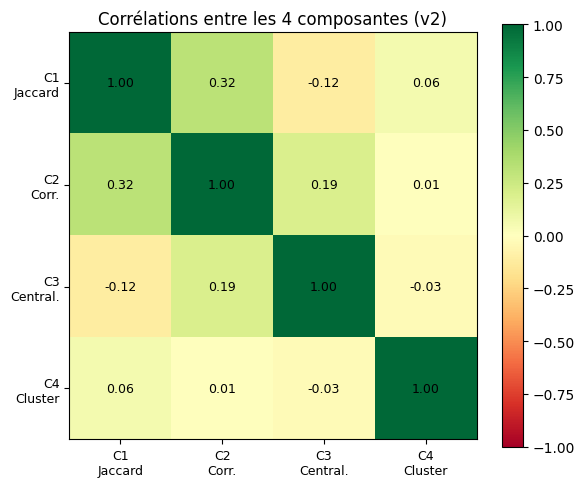


→ Si toutes les corrélations hors-diagonale sont < 0.10,
  la pondération explicite est confirmée comme méthode d'agrégation.


In [11]:
corr_matrix = panel[norm_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
labels_short = ["C1\nJaccard", "C2\nCorr.", "C3\nCentral.", "C4\nCluster"]
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_yticklabels(labels_short, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}",
                ha="center", va="center", fontsize=9)
ax.set_title("Corrélations entre les 4 composantes (v2)")
plt.tight_layout()
plt.show()

print("\n→ Si toutes les corrélations hors-diagonale sont < 0.10,")
print("  la pondération explicite est confirmée comme méthode d'agrégation.")

---
## Agrégation v2 : pondération explicite

**Abandon de la PCA** : les 4 composantes sont quasi-orthogonales (corr < 0.10),
la PCA dans ce cas sélectionne mécaniquement la variable de plus grande variance.
Ce n'est pas une limitation de notre approche — c'est une confirmation que
les 4 dimensions sont genuinement distinctes.

**Poids retenus** : C1=0.40, C2=0.25, C3=0.20, C4=0.15
- C1 > C2 : le Jaccard est la seule composante à valider correctement le ground truth en v1.
  La corrélation (C2) est filtrée et ne contribue que sur les paires avec signal robuste.
- C3 > C4 : la centralité est disponible pour toutes les paires, le cluster absorbant
  ne concerne qu'une minorité de paires (signal plus rare mais plus fort).

**Analyse de sensibilité** : on calcule aussi des variantes pour tester la robustesse.

In [12]:
# ── indice principal ─────────────────────────────────────────────────────────
panel["CI_v2"] = sum(W[col] * panel[col] for col in norm_cols)

# normalisation finale [0,1]
panel["CI_v2"] = MinMaxScaler().fit_transform(
    panel["CI_v2"].values.reshape(-1, 1)
).flatten()

# ── variantes de robustesse ──────────────────────────────────────────────────
# Variante A : C1 seul (baseline)
panel["CI_C1_only"] = panel["C1_jaccard"]

# Variante B : poids égaux
panel["CI_equal"] = MinMaxScaler().fit_transform(
    panel[norm_cols].mean(axis=1).values.reshape(-1, 1)
).flatten()

# Variante C : sans C2 (pour mesurer la contribution de la corrélation)
w_no_c2 = {"C1_jaccard": 0.50, "C3_centrality": 0.30, "C4_cluster": 0.20}
panel["CI_no_c2"] = MinMaxScaler().fit_transform(
    sum(w * panel[col] for col, w in w_no_c2.items()).values.reshape(-1, 1)
).flatten()

print(f"CI_v2 : mean={panel['CI_v2'].mean():.4f}, std={panel['CI_v2'].std():.4f}")
print()
print("Corrélations entre variantes :")
panel[["CI_v2", "CI_C1_only", "CI_equal", "CI_no_c2"]].corr().round(3)

CI_v2 : mean=0.1399, std=0.1419

Corrélations entre variantes :


,CI_v2,CI_C1_only,CI_equal,CI_no_c2
CI_v2,1.000,0.492,0.988,0.594
CI_C1_only,0.492,1.000,0.406,0.634
CI_equal,0.988,0.406,1.000,0.628
CI_no_c2,0.594,0.634,0.628,1.000


---
## Validation sur les cas connus (ground truth)

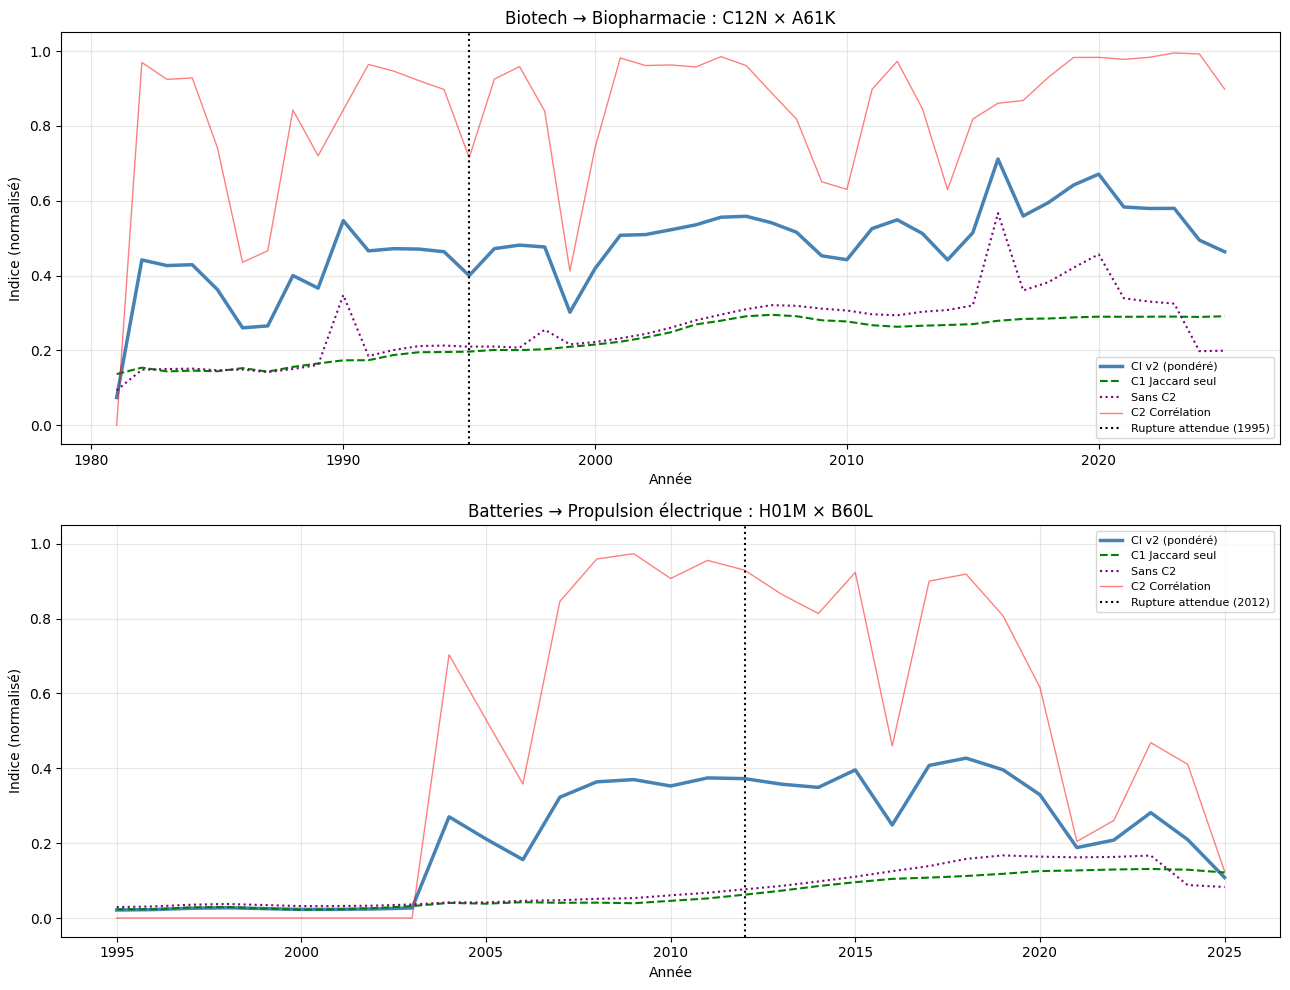

In [13]:
def plot_pair_validation(panel, ci, cj, label, expected_break, ax=None):
    mask = (
        ((panel["cpc_i"] == ci) & (panel["cpc_j"] == cj)) |
        ((panel["cpc_i"] == cj) & (panel["cpc_j"] == ci))
    )
    sub = panel[mask].sort_values("year")

    if len(sub) == 0:
        print(f"⚠ Paire {ci}×{cj} absente du panel (filtre n_cooc trop strict ?)")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(sub["year"], sub["CI_v2"],      label="CI v2 (pondéré)",  color="steelblue",  lw=2.5)
    ax.plot(sub["year"], sub["CI_C1_only"], label="C1 Jaccard seul",  color="green",      lw=1.5, ls="--")
    ax.plot(sub["year"], sub["CI_no_c2"],   label="Sans C2",          color="purple",     lw=1.5, ls=":")
    ax.plot(sub["year"], sub["C2_corr"],    label="C2 Corrélation",   color="red",        lw=1,   alpha=0.5)
    ax.axvline(expected_break, color="black", ls=":", lw=1.5,
               label=f"Rupture attendue ({expected_break})")
    ax.set_title(f"{label} : {ci} × {cj}")
    ax.set_xlabel("Année")
    ax.set_ylabel("Indice (normalisé)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(13, 10))
plot_pair_validation(panel, "C12N", "A61K",
                     "Biotech → Biopharmacie", expected_break=1995, ax=axes[0])
plot_pair_validation(panel, "H01M", "B60L",
                     "Batteries → Propulsion électrique", expected_break=2012, ax=axes[1])
plt.tight_layout()
plt.savefig("validation_ground_truth_v2.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Top convergences par année (v2)

In [14]:
def top_convergences(panel, year, n=10):
    return (
        panel[panel["year"] == year]
        .nlargest(n, "CI_v2")[["cpc_i", "cpc_j", "CI_v2",
                                 "C1_jaccard", "C2_corr",
                                 "C3_centrality", "C4_cluster", "n_cooc"]]
        .reset_index(drop=True)
    )

# test : les paires du top 10 doivent avoir du sens économique
for yr in [1990, 2000, 2010, 2020]:
    print(f"\n── Top 10 convergences en {yr} ──────────────────────────────")
    display(top_convergences(panel, yr, n=10))


── Top 10 convergences en 1990 ──────────────────────────────


,cpc_i,cpc_j,CI_v2,C1_jaccard,C2_corr,C3_centrality,C4_cluster,n_cooc
0,C10M,C10N,0.914175,0.811651,0.971098,0.019747,0.671856,209
1,A61P,C07D,0.843898,0.524325,0.959184,0.383258,0.628892,1986
2,G06Q,G07F,0.788421,0.619359,0.905946,0.023649,0.671856,160
3,E05D,E05Y,0.718031,0.704431,0.971572,0.016697,0.000000,154
4,F02B,Y02T,0.711065,0.406897,0.954437,0.103693,0.671856,514
5,C07K,C12N,0.681039,0.368586,0.953438,0.103447,0.628892,515
6,A61K,C07K,0.669063,0.350961,0.911198,0.147490,0.628892,723
7,C01P,C09C,0.654563,0.529231,0.657895,0.022071,0.671856,187
8,E05F,E05Y,0.646061,0.632596,0.870740,0.015038,0.009195,133
9,A01N,C07D,0.645369,0.250203,0.921356,0.249237,0.628892,737



── Top 10 convergences en 2000 ──────────────────────────────


,cpc_i,cpc_j,CI_v2,C1_jaccard,C2_corr,C3_centrality,C4_cluster,n_cooc
0,A61K,A61P,0.697392,0.500890,0.964671,0.356561,0.000000,3072
1,A61P,C07D,0.672113,0.484992,0.896649,0.380490,0.000000,2816
2,E05F,E05Y,0.666653,0.696570,0.823276,0.018362,0.014168,242
3,C01P,C09C,0.666020,0.594120,0.979458,0.025704,0.014168,347
4,G06Q,G07F,0.622476,0.613594,0.741739,0.043760,0.121008,416
5,A61K,C07K,0.619107,0.441232,0.927999,0.234035,0.000000,2002
6,E05D,E05Y,0.583707,0.575113,0.774830,0.017021,0.014168,194
7,A43B,A63C,0.567052,0.393561,0.997773,0.009611,0.055007,52
8,C10M,C10N,0.567021,0.807217,0.354709,0.016645,0.014168,237
9,A61P,C07K,0.564312,0.314337,0.945659,0.264390,0.000000,1575



── Top 10 convergences en 2010 ──────────────────────────────


,cpc_i,cpc_j,CI_v2,C1_jaccard,C2_corr,C3_centrality,C4_cluster,n_cooc
0,C10M,C10N,0.891980,0.949370,0.960448,0.008962,0.227986,263
1,A61K,A61P,0.823051,0.655359,0.968072,0.505145,0.000000,9374
2,E05F,E05Y,0.751934,0.691521,0.952116,0.020435,0.227986,451
3,H01M,Y02E,0.750710,0.657494,0.996389,0.199640,0.000000,3869
4,A61P,C07D,0.723831,0.517212,0.926322,0.469014,0.000000,6528
5,C01P,C09C,0.706737,0.646078,0.892335,0.019957,0.227986,524
6,F03D,F05B,0.675105,0.649659,0.931760,0.018259,0.000000,430
7,F21V,F21Y,0.673487,0.566050,0.924636,0.017449,0.227986,379
8,F01D,F05D,0.669052,0.714702,0.715011,0.058104,0.105020,1217
9,B29C,B29L,0.665051,0.553872,0.857337,0.094929,0.227986,2063



── Top 10 convergences en 2020 ──────────────────────────────


,cpc_i,cpc_j,CI_v2,C1_jaccard,C2_corr,C3_centrality,C4_cluster,n_cooc
0,A61K,A61P,1.000000,0.798175,0.994405,0.561669,0.366903,18287
1,C10M,C10N,0.873401,0.960508,0.997750,0.019649,0.030834,819
2,F28D,F28F,0.867689,0.681306,0.973192,0.066952,0.725246,2109
3,F03D,F05B,0.836733,0.749454,0.998260,0.079609,0.333181,2665
4,F21V,F21Y,0.836011,0.660758,0.921630,0.056088,0.725246,1989
5,E05F,E05Y,0.827133,0.655635,0.924073,0.030657,0.725246,896
6,F01D,F05D,0.823022,0.777739,0.996075,0.225276,0.000000,7505
7,G06F,H04L,0.784716,0.415123,0.998523,0.806679,0.000000,12341
8,A61P,C07D,0.747206,0.411276,0.995984,0.404525,0.366903,7524
9,E05D,E05Y,0.744985,0.572790,0.816144,0.029381,0.725246,767


---
## Évolution temporelle de l'indice agrégé (v2)

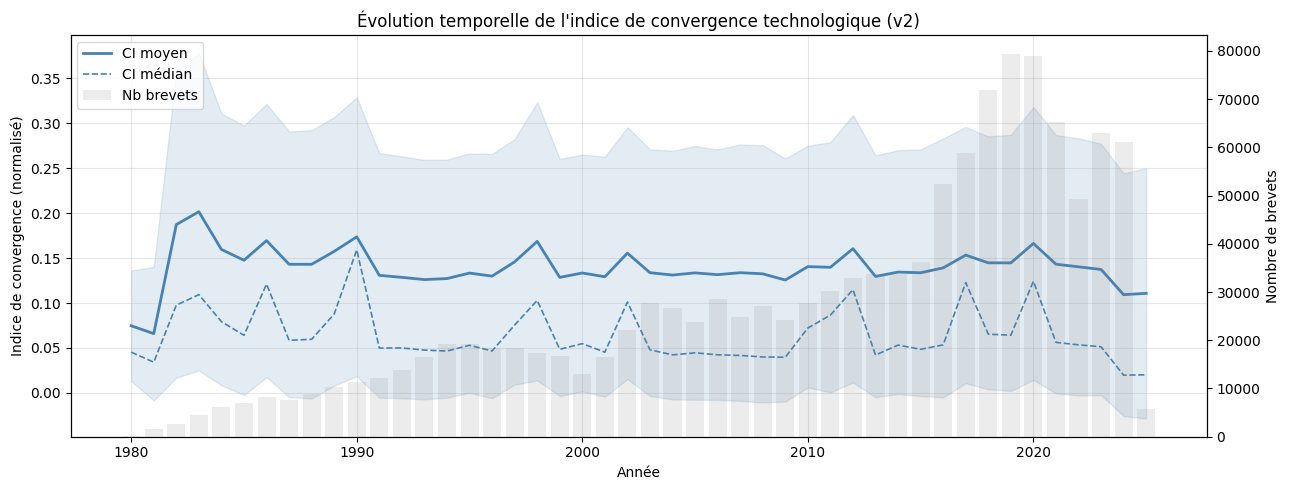


→ On attend maintenant une tendance croissante (espace technologique de plus en plus
  interconnecté) et des accélérations autour de 1990-1995 (biotech) et 2010-2015 (IA).


In [15]:
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")

CI_time = (
    panel.groupby("year")["CI_v2"]
    .agg(["mean", "median", "std"])
    .join(yearly_patents)
)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    CI_time.index,
    CI_time["mean"] - CI_time["std"],
    CI_time["mean"] + CI_time["std"],
    alpha=0.15, color="steelblue"
)
ax1.plot(CI_time.index, CI_time["mean"],   label="CI moyen",  color="steelblue", lw=2)
ax1.plot(CI_time.index, CI_time["median"], label="CI médian", color="steelblue", lw=1.2, ls="--")
ax2.bar(CI_time.index, CI_time["n_patents"], alpha=0.15, color="gray", label="Nb brevets")

ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de convergence (normalisé)")
ax2.set_ylabel("Nombre de brevets")
ax1.set_title("Évolution temporelle de l'indice de convergence technologique (v2)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("CI_temporal_v2.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ On attend maintenant une tendance croissante (espace technologique de plus en plus")
print("  interconnecté) et des accélérations autour de 1990-1995 (biotech) et 2010-2015 (IA).")

---
## Export final

In [ ]:
cols_export = [
    "cpc_i", "cpc_j", "year",
    "C1_jaccard", "C2_corr", "C3_centrality", "C4_cluster",
    "CI_v2", "CI_C1_only", "CI_equal", "CI_no_c2",
    "jaccard", "jaccard_log",
    "p_j_given_i", "p_i_given_j",
    "rolling_corr", "n_cooc"
]
panel[cols_export].to_parquet("indice_convergence_v2.parquet", index=False)
panel[cols_export].to_csv("indice_convergence_v2.csv", index=False)

print("Fichiers exportés : indice_convergence_v2.parquet / .csv")
print(f"  → {len(panel):,} lignes, {panel['year'].nunique()} années")
panel[cols_export].describe()